# Stage 4 — Result Visualisations

**Thesis:** *Temporal Granularity and Forecast Configuration for Zero-Shot Energy Forecasting —
A Scenario-Oriented Evaluation of Time-Series Foundation Models*

This notebook renders the key findings of the refined pipeline (stages 3a–3k) as
publication-quality figures. It reads the `refined_stage3*.csv` outputs, aggregates with the
**median relMAE** (robust to benchmark-near-zero outliers), and writes each figure to
`figures/` as PNG + PDF while also displaying it inline.

Run top to bottom. Each section states the finding, then draws it.

| # | Figure | Answers |
|---|---|---|
| 0 | Zero-inflation by type & granularity | data basis for H4 |
| 1 | Context sweep (three regimes) | RQ2 — context |
| 2 | Horizon sweep | RQ2 — horizon |
| 3 | Granularity by physical lead time | RQ1 |
| 4 | Accuracy vs inference cost (Pareto) | RQ3 |
| 5 | Descriptor transfer (leave-one-type-out) | RQ4 |
| 6 | Benchmark robustness (seasonal-naive vs random-walk) | robustness |
| 7 | Best relMAE by model × cell | model comparison |

## Setup — imports, palette, and data loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib inline

# --- where the CSVs live (thesis root by default) ---
DATA_DIR = Path(".")
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

ETYPES = ["load", "solar", "wind"]
ETYPE_TITLE = {"load": "Electricity demand", "solar": "Solar", "wind": "Wind"}

# Okabe-Ito colourblind-safe palette
GRAN_COLOR = {"native": "#0072B2", "hourly": "#E69F00", "daily": "#009E73"}
GRAN_ORDER = ["native", "hourly", "daily"]
GRAN_LABELMAP = {"minutes (native)": "native", "native": "native", "hourly": "hourly",
                 "daily": "daily", "1h": "hourly", "1D": "daily"}
MODEL_COLOR = {"chronos": "#0072B2", "timesfm": "#D55E00", "moirai": "#009E73"}
MODEL_ORDER = ["chronos", "timesfm", "moirai"]
MODEL_TITLE = {"chronos": "Chronos", "timesfm": "TimesFM", "moirai": "Moirai"}
INK, MUTED = "#222222", "#777777"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10.5, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "axes.axisbelow": True, "grid.color": "#E6E6E6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#666666", "axes.linewidth": 0.9, "xtick.color": "#444444",
    "ytick.color": "#444444", "axes.labelcolor": "#222222", "text.color": "#222222",
    "legend.frameon": False, "figure.facecolor": "white",
})

def norm_gran(s):
    return s.map(lambda x: GRAN_LABELMAP.get(str(x), str(x)))

def load(name):
    return pd.read_csv(DATA_DIR / name)

def savefig(fig, stem):
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    print(f"saved figures/{stem}.png / .pdf")

def gran_legend(fig, grans=GRAN_ORDER):
    h = [Line2D([0], [0], color=GRAN_COLOR[g], lw=2.4, marker="o", ms=5, label=g) for g in grans]
    fig.legend(handles=h, loc="lower center", ncol=len(grans), bbox_to_anchor=(0.5, -0.03), fontsize=10)

print("Reading from:", DATA_DIR.resolve())
print("CSV files found:", len(list(DATA_DIR.glob("refined_stage3*.csv"))))

Reading from: /home/claude
CSV files found: 8


## 0 · Zero-inflation by type and granularity

The data basis for **H4**. Solar is **55 % exact zeros** at native resolution (night), falling to
**0 % at daily** — a clean natural experiment. Wind stays zero-inflated at every resolution, which
is why the same aggregation mechanism does not rescue it.

saved figures/fig0_data_characteristics_zero_inflation.png / .pdf


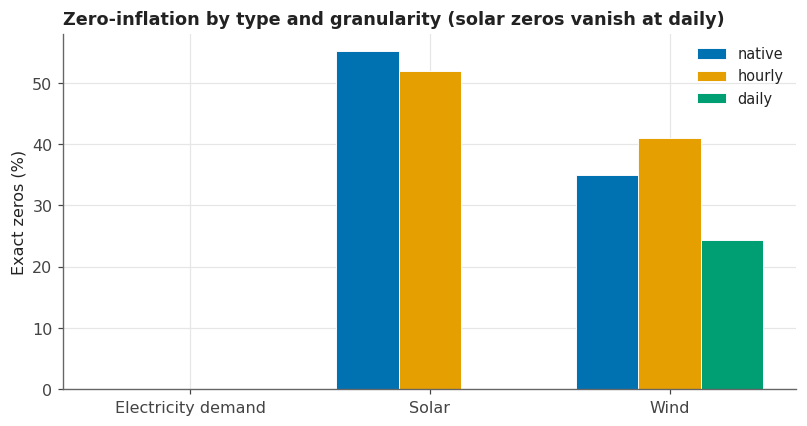

In [2]:
d = load("refined_stage3a_characteristics.csv"); d["g"] = norm_gran(d["gran"])
g = d.groupby(["etype", "g"]).pct_zero.mean().reset_index()

fig, ax = plt.subplots(figsize=(8.6, 4.2))
x = np.arange(len(ETYPES)); w = 0.26
for i, gran in enumerate(GRAN_ORDER):
    vals = [float(g[(g.etype == e) & (g.g == gran)].pct_zero.iloc[0])
            if not g[(g.etype == e) & (g.g == gran)].empty else np.nan for e in ETYPES]
    ax.bar(x + (i - 1) * w, vals, w, color=GRAN_COLOR[gran], label=gran, edgecolor="white", linewidth=0.6)
ax.set_xticks(x); ax.set_xticklabels([ETYPE_TITLE[e] for e in ETYPES])
ax.set_ylabel("Exact zeros (%)")
ax.set_title("Zero-inflation by type and granularity (solar zeros vanish at daily)",
             fontsize=11.5, fontweight="bold", loc="left")
ax.legend(fontsize=9.5)
savefig(fig, "fig0_data_characteristics_zero_inflation"); plt.show()

## 1 · RQ2 — Context sweep: three regimes

**More history helps demand, is flat for solar, and *harms* wind.** Demand carries daily, weekly and
seasonal structure and keeps improving out to 2048 steps; solar is one dominant cycle plus noise
(flat); wind is close to a random walk, so extra context dilutes the recent state that carries the
forecast. Dashed line = 1.0 (seasonal-naive).

saved figures/fig1_rq2_context_sweep.png / .pdf


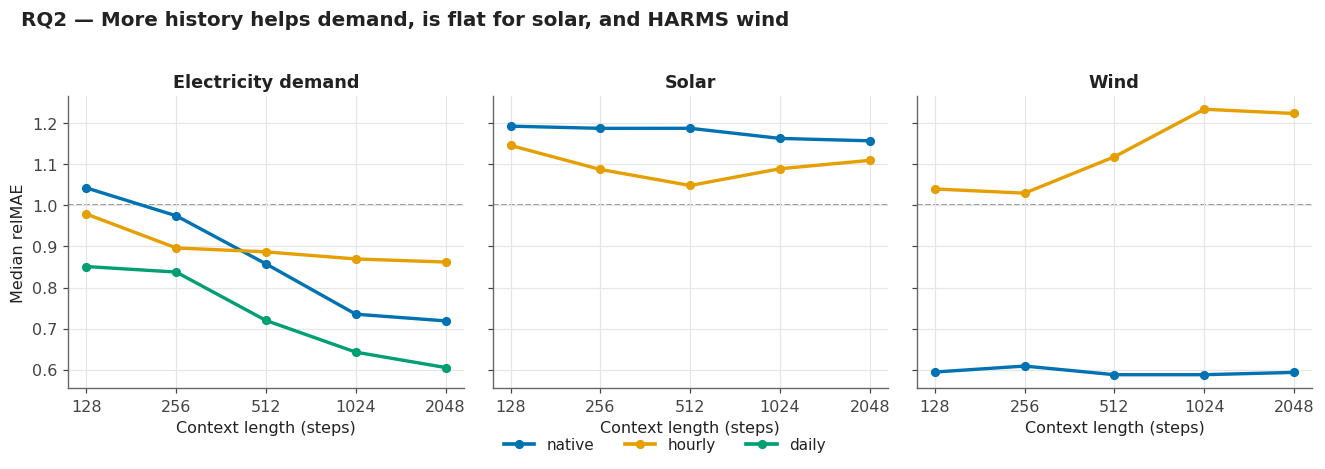

In [3]:
d = load("refined_stage3b_context_sweep.csv"); d = d[d.degenerate == False].copy(); d["g"] = norm_gran(d.gran_label)
g = d.groupby(["etype", "g", "context_steps"]).relMAE.median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.1), sharey=True)
for ax, et in zip(axes, ETYPES):
    sub = g[g.etype == et]
    for gran in GRAN_ORDER:
        s = sub[sub.g == gran].sort_values("context_steps")
        if not s.empty:
            ax.plot(s.context_steps, s.relMAE, color=GRAN_COLOR[gran], lw=2.2, marker="o", ms=5)
    ax.axhline(1.0, color=MUTED, lw=1.0, ls="--", zorder=0)
    ax.set_xscale("log", base=2); ax.set_xticks([128, 256, 512, 1024, 2048])
    ax.set_xticklabels(["128", "256", "512", "1024", "2048"])
    ax.set_title(ETYPE_TITLE[et], fontsize=11.5, fontweight="bold"); ax.set_xlabel("Context length (steps)")
axes[0].set_ylabel("Median relMAE")
fig.suptitle("RQ2 — More history helps demand, is flat for solar, and HARMS wind",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
gran_legend(fig); fig.tight_layout(rect=(0, 0, 1, 0.96))
savefig(fig, "fig1_rq2_context_sweep"); plt.show()

## 2 · RQ2 — Horizon sweep

Horizon is the dominant lever wherever metering is fine: **degradation is far steeper at native
resolution** (solar native nearly doubles from 6→48 steps) than at daily, where load even improves.
This corroborates RQ1 from the other direction.

saved figures/fig2_rq2_horizon_sweep.png / .pdf


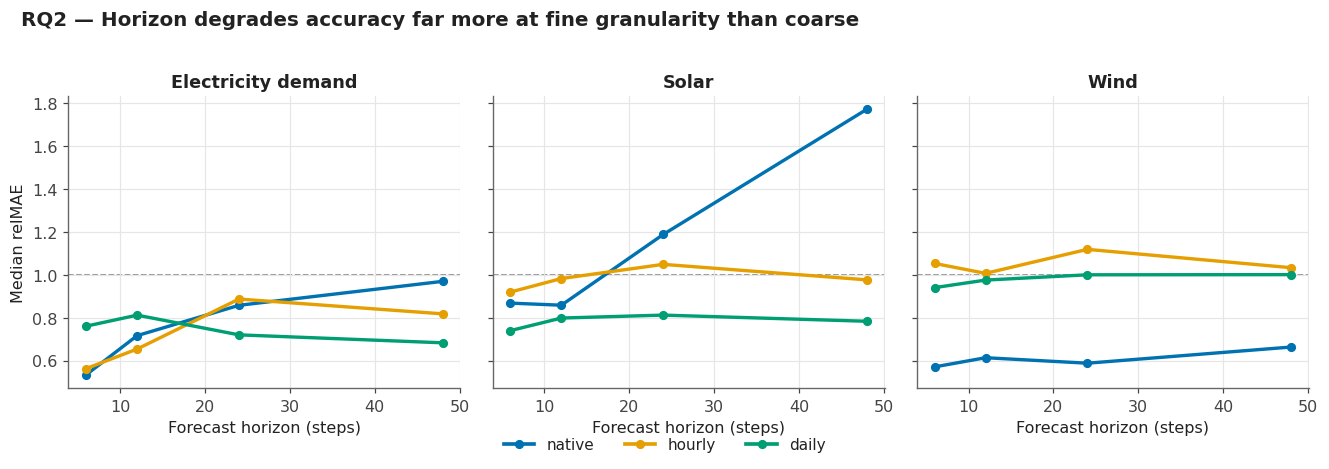

In [4]:
d = load("refined_stage3c_horizon_sweep.csv"); d = d[d.degenerate == False].copy(); d["g"] = norm_gran(d.gran_label)
g = d.groupby(["etype", "g", "horizon_steps"]).relMAE.median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.1), sharey=True)
for ax, et in zip(axes, ETYPES):
    sub = g[g.etype == et]
    for gran in GRAN_ORDER:
        s = sub[sub.g == gran].sort_values("horizon_steps")
        if not s.empty:
            ax.plot(s.horizon_steps, s.relMAE, color=GRAN_COLOR[gran], lw=2.2, marker="o", ms=5)
    ax.axhline(1.0, color=MUTED, lw=1.0, ls="--", zorder=0)
    ax.set_title(ETYPE_TITLE[et], fontsize=11.5, fontweight="bold"); ax.set_xlabel("Forecast horizon (steps)")
axes[0].set_ylabel("Median relMAE")
fig.suptitle("RQ2 — Horizon degrades accuracy far more at fine granularity than coarse",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
gran_legend(fig); fig.tight_layout(rect=(0, 0, 1, 0.96))
savefig(fig, "fig2_rq2_horizon_sweep"); plt.show()

## 3 · RQ1 — Optimal granularity tracks lead time

De-confounded in physical time (40-day history). At a **1 h lead the resolution barely matters**;
from ~6 h ahead the **coarser representation wins**, and by 24–48 h daily aggregation is best on
every type that can be compared there. Only leads with ≥ 2 feasible granularities are shown.

saved figures/fig3_rq1_granularity_by_lead.png / .pdf


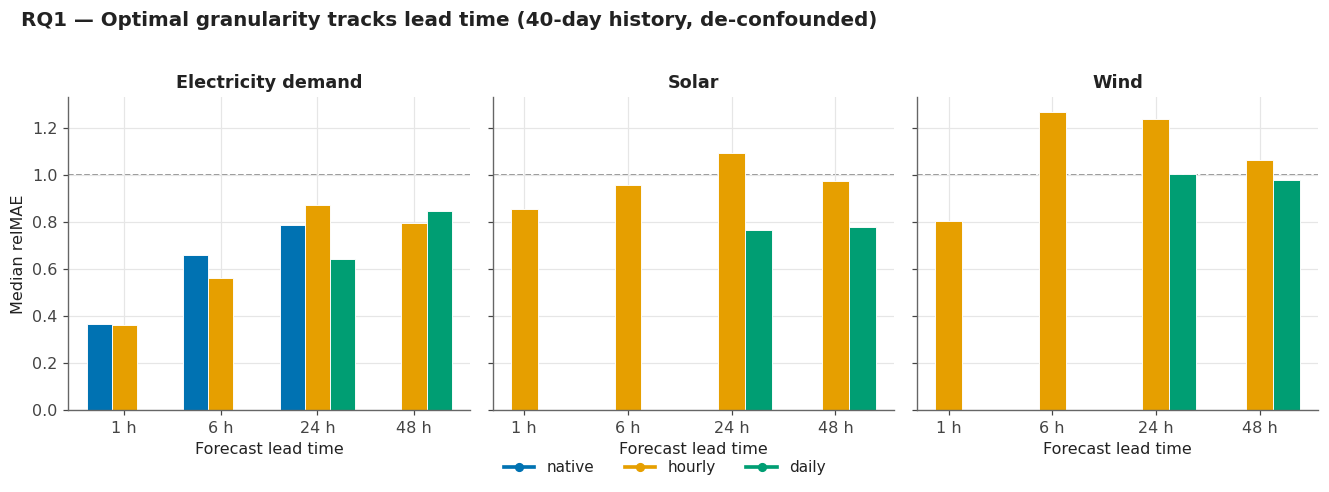

In [5]:
d = load("refined_stage3d_fixed_lead_time.csv"); d = d[d.degenerate == False].copy(); d["g"] = norm_gran(d.gran_label)
d = d[d.history == "40 d"]; lead_order = ["1 h", "6 h", "24 h", "48 h"]
d = d[d.lead.isin(lead_order)]
g = d.groupby(["etype", "lead", "g"]).relMAE.median().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.3), sharey=True)
for ax, et in zip(axes, ETYPES):
    sub = g[g.etype == et]; leads = [l for l in lead_order if l in sub.lead.unique()]
    x = np.arange(len(leads)); w = 0.26
    for i, gran in enumerate(GRAN_ORDER):
        vals = [sub[(sub.lead == l) & (sub.g == gran)].relMAE.median() for l in leads]
        ax.bar(x + (i - 1) * w, vals, w, color=GRAN_COLOR[gran], edgecolor="white", linewidth=0.6)
    ax.axhline(1.0, color=MUTED, lw=1.0, ls="--", zorder=0)
    ax.set_xticks(x); ax.set_xticklabels(leads)
    ax.set_title(ETYPE_TITLE[et], fontsize=11.5, fontweight="bold"); ax.set_xlabel("Forecast lead time")
axes[0].set_ylabel("Median relMAE")
fig.suptitle("RQ1 — Optimal granularity tracks lead time (40-day history, de-confounded)",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
gran_legend(fig); fig.tight_layout(rect=(0, 0, 1, 0.96))
savefig(fig, "fig3_rq1_granularity_by_lead"); plt.show()

## 4 · RQ3 — Accuracy vs inference cost (Pareto frontier)

Once cost counts, **filled markers are Pareto-optimal** and faded markers are dominated (both slower
and less accurate than an alternative). TimesFM wins raw accuracy at ~17× the cost, so it earns its
place only on load; **Chronos owns the solar and wind frontiers.**

saved figures/fig4_rq3_pareto_cost.png / .pdf


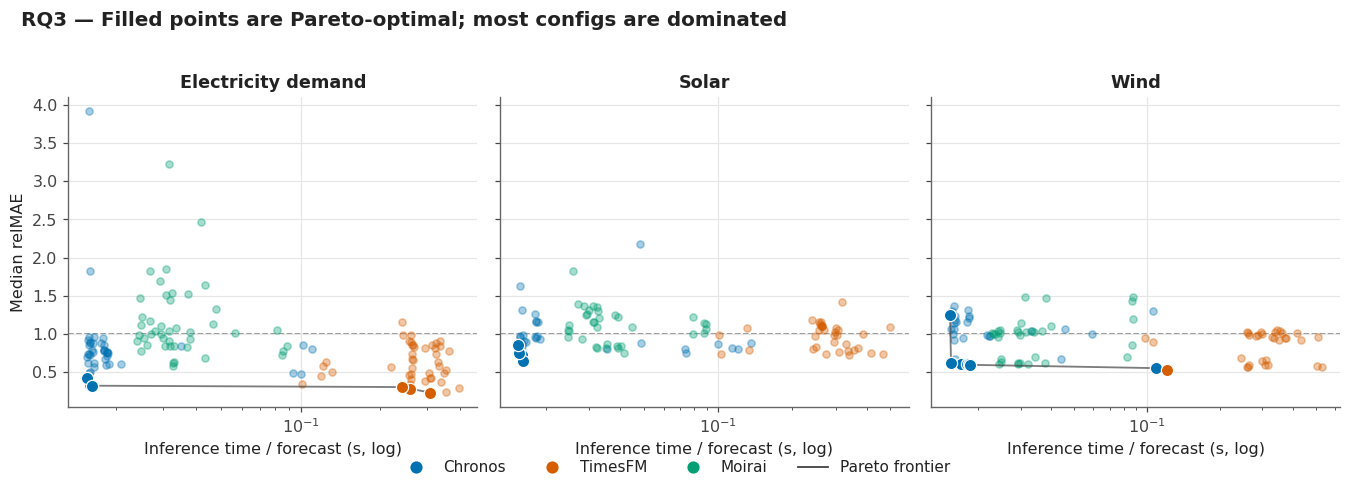

In [6]:
d = load("refined_stage3j_configurations_with_cost.csv")
fig, axes = plt.subplots(1, 3, figsize=(12.4, 4.3), sharey=True)
for ax, et in zip(axes, ETYPES):
    sub = d[d.etype == et]
    for model in MODEL_ORDER:
        s = sub[sub.model == model]
        dom, par = s[~s.pareto], s[s.pareto]
        ax.scatter(dom.infer_sec, dom.median_relMAE, s=22, color=MODEL_COLOR[model], alpha=0.35, zorder=2)
        ax.scatter(par.infer_sec, par.median_relMAE, s=64, color=MODEL_COLOR[model],
                   edgecolor="white", linewidth=0.8, zorder=4)
    pf = sub[sub.pareto].sort_values("infer_sec")
    if not pf.empty:
        ax.plot(pf.infer_sec, pf.median_relMAE, color="#444444", lw=1.2, zorder=3, alpha=0.7)
    ax.axhline(1.0, color=MUTED, lw=1.0, ls="--", zorder=0); ax.set_xscale("log")
    ax.set_title(ETYPE_TITLE[et], fontsize=11.5, fontweight="bold"); ax.set_xlabel("Inference time / forecast (s, log)")
axes[0].set_ylabel("Median relMAE")
h = [Line2D([0], [0], marker="o", color="none", markerfacecolor=MODEL_COLOR[m], markeredgecolor="white",
            ms=9, label=MODEL_TITLE[m]) for m in MODEL_ORDER]
h.append(Line2D([0], [0], color="#444444", lw=1.2, label="Pareto frontier"))
fig.legend(handles=h, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.03), fontsize=10)
fig.suptitle("RQ3 — Filled points are Pareto-optimal; most configs are dominated",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.96))
savefig(fig, "fig4_rq3_pareto_cost"); plt.show()

## 5 · RQ4 — Descriptor transfer (leave-one-type-out)

A rule built on measurable series descriptors (zero-inflation, volatility, seasonal strength)
**transfers to two of three** held-out energy types (solar ρ = +0.82). It fails onto wind because
wind's own mean already predicts its performance — little variance remains to explain.

saved figures/fig5_rq4_descriptor_transfer.png / .pdf


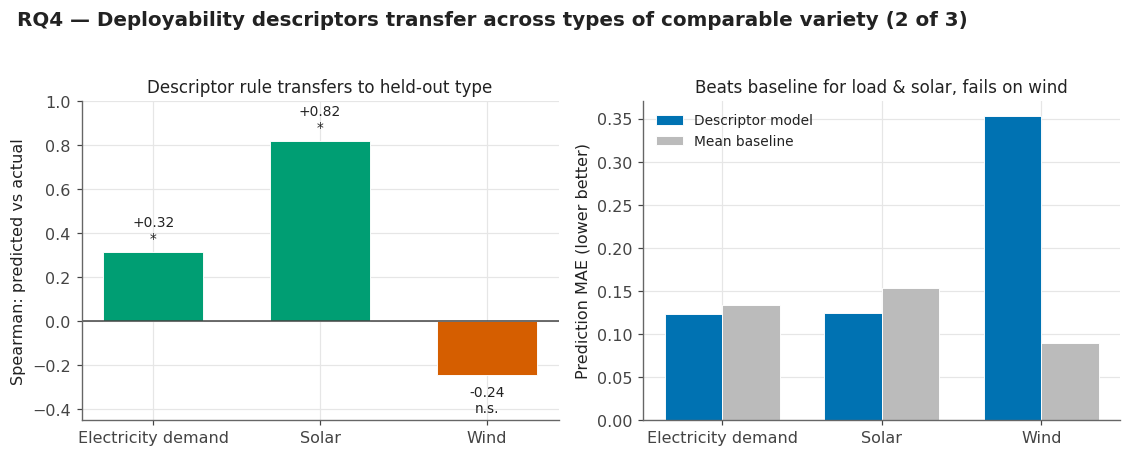

In [7]:
d = load("refined_stage3g_leave_one_type_out.csv")
d["etype"] = pd.Categorical(d.held_out, ETYPES, ordered=True); d = d.sort_values("etype")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.2)); x = np.arange(len(d))
colors = ["#009E73" if b else "#D55E00" for b in d.beats_baseline]
ax1.bar(x, d.spearman_pred_vs_actual, color=colors, width=0.6, edgecolor="white", linewidth=0.6)
ax1.axhline(0, color="#444444", lw=1.0)
for xi, (_, r) in zip(x, d.iterrows()):
    yv = r.spearman_pred_vs_actual; sig = "*" if r.p < 0.05 else "n.s."
    ax1.text(xi, yv + (0.03 if yv >= 0 else -0.05), f"{yv:+.2f}\n{sig}",
             ha="center", va="bottom" if yv >= 0 else "top", fontsize=9)
ax1.set_xticks(x); ax1.set_xticklabels([ETYPE_TITLE[e] for e in d.held_out])
ax1.set_ylabel("Spearman: predicted vs actual"); ax1.set_ylim(-0.45, 1.0)
ax1.set_title("Descriptor rule transfers to held-out type", fontsize=11)
w = 0.36
ax2.bar(x - w/2, d.MAE_model, w, color="#0072B2", label="Descriptor model", edgecolor="white", linewidth=0.6)
ax2.bar(x + w/2, d.MAE_mean_baseline, w, color="#BBBBBB", label="Mean baseline", edgecolor="white", linewidth=0.6)
ax2.set_xticks(x); ax2.set_xticklabels([ETYPE_TITLE[e] for e in d.held_out])
ax2.set_ylabel("Prediction MAE (lower better)")
ax2.set_title("Beats baseline for load & solar, fails on wind", fontsize=11); ax2.legend(fontsize=9)
fig.suptitle("RQ4 — Deployability descriptors transfer across types of comparable variety (2 of 3)",
             fontsize=13, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))
savefig(fig, "fig5_rq4_descriptor_transfer"); plt.show()

## 6 · Benchmark robustness — the wind question

relMAE divides by a seasonal-naive benchmark; for wind (no reliable daily cycle) that benchmark is
inappropriately weak. Re-scored against a **random-walk** benchmark, **wind native's apparent skill
vanishes** (0.61 → 0.99). Solar's daily cycle is real, so it beats both legitimately; load is robust
either way.

saved figures/fig6_benchmark_robustness.png / .pdf


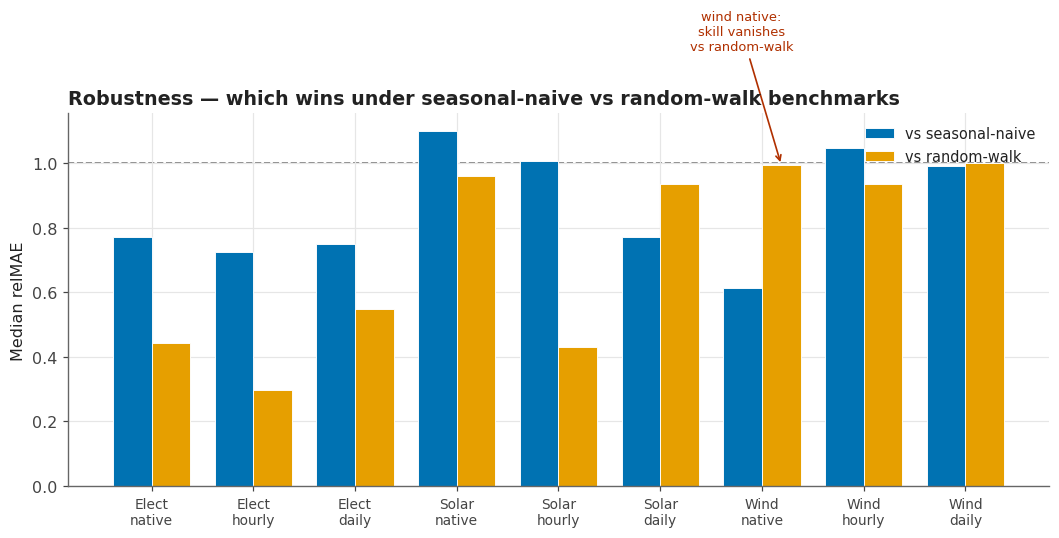

In [8]:
d = load("refined_stage3k_benchmark_comparison.csv"); d["g"] = norm_gran(d.gran)
cells = [(e, gr, d[(d.etype == e) & (d.g == gr)].iloc[0])
         for e in ETYPES for gr in ["native", "hourly", "daily"]
         if not d[(d.etype == e) & (d.g == gr)].empty]
labels = [f"{ETYPE_TITLE[e][:5]}\n{gr}" for e, gr, _ in cells]
sea = [r.relMAE_seasonal for _, _, r in cells]; rw = [r.relMAE_randomwalk for _, _, r in cells]
x = np.arange(len(cells)); w = 0.38

fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.bar(x - w/2, sea, w, color="#0072B2", label="vs seasonal-naive", edgecolor="white", linewidth=0.6)
ax.bar(x + w/2, rw, w, color="#E69F00", label="vs random-walk", edgecolor="white", linewidth=0.6)
ax.axhline(1.0, color=MUTED, lw=1.1, ls="--", zorder=0)
for i, (e, gr, _) in enumerate(cells):
    if e == "wind" and gr == "native":
        ax.annotate("wind native:\nskill vanishes\nvs random-walk", xy=(i + w/2, rw[i]),
                    xytext=(i - 0.2, 1.35), fontsize=8.5, color="#B03000", ha="center",
                    arrowprops=dict(arrowstyle="->", color="#B03000", lw=1.1))
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9); ax.set_ylabel("Median relMAE")
ax.legend(fontsize=9.5, loc="upper right")
ax.set_title("Robustness — which wins under seasonal-naive vs random-walk benchmarks",
             fontsize=12.5, fontweight="bold", loc="left")
savefig(fig, "fig6_benchmark_robustness"); plt.show()

## 7 · Best achievable relMAE by model × cell

Best configuration per cell for each model. TimesFM's green load column is its raw-accuracy edge;
everyone struggles on wind daily. *Caveat:* Moirai's `patch_size` is left at the default (32), so its
last place is provisional.

saved figures/fig7_model_cell_overview.png / .pdf


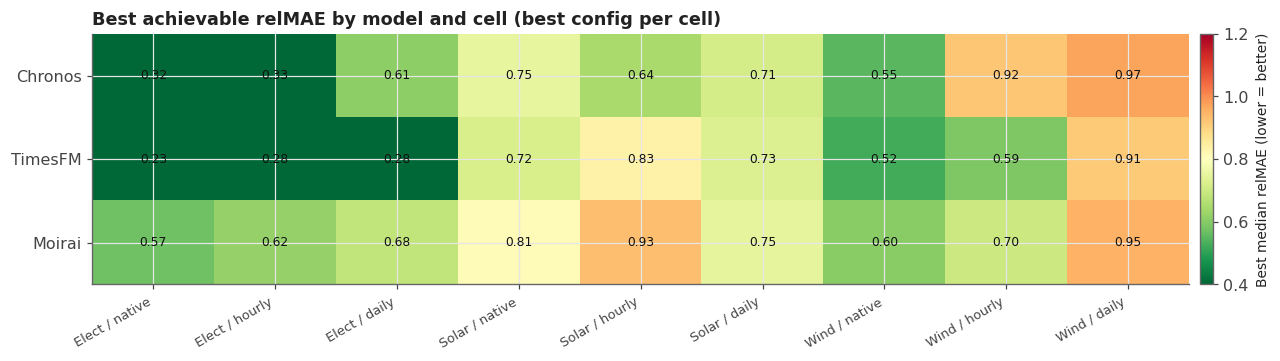

In [9]:
d = load("refined_stage3f_all_configurations.csv"); d["g"] = norm_gran(d.gran_label)
best = d.groupby(["etype", "g", "model"]).median_relMAE.min().reset_index()
cells = [(e, gr) for e in ETYPES for gr in ["native", "hourly", "daily"]
         if not best[(best.etype == e) & (best.g == gr)].empty]
labels = [f"{ETYPE_TITLE[c[0]][:5]} / {c[1]}" for c in cells]
M = np.full((len(MODEL_ORDER), len(cells)), np.nan)
for j, (e, gr) in enumerate(cells):
    for i, m in enumerate(MODEL_ORDER):
        r = best[(best.etype == e) & (best.g == gr) & (best.model == m)]
        if not r.empty: M[i, j] = r.iloc[0].median_relMAE

fig, ax = plt.subplots(figsize=(11.8, 3.4))
im = ax.imshow(M, aspect="auto", cmap="RdYlGn_r", vmin=0.4, vmax=1.2)
ax.set_xticks(np.arange(len(cells))); ax.set_xticklabels(labels, fontsize=8.5, rotation=30, ha="right")
ax.set_yticks(np.arange(len(MODEL_ORDER))); ax.set_yticklabels([MODEL_TITLE[m] for m in MODEL_ORDER])
for i in range(len(MODEL_ORDER)):
    for j in range(len(cells)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8, color="#111111")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01); cb.set_label("Best median relMAE (lower = better)", fontsize=9)
ax.set_title("Best achievable relMAE by model and cell (best config per cell)",
             fontsize=11.5, fontweight="bold", loc="left")
fig.tight_layout()
savefig(fig, "fig7_model_cell_overview"); plt.show()

---
### Notes & caveats
- **Metric:** relMAE = forecast MAE ÷ horizon-matched seasonal-naive MAE. Below 1.0 beats the benchmark.
  Figures pool over models/series with the **median**.
- **n = 5 series per type** caps power — the cause of RQ2's underpowered interaction. Solar (137) and
  wind (339) are scalable (strongest next step).
- **Pretraining contamination:** some datasets appear in the models' pretraining corpora — frame
  "zero-shot" as "no task-specific fine-tuning".
- **Moirai `patch_size = 32`** (reference uses `"auto"`) and capacity confounded with model identity —
  both limit the model-ranking claims.

Re-run any stage and re-execute this notebook to refresh all figures in `figures/`.